# AICE Associate 예상 문제 2회: 부동산 가격 예측

**과제: 지역별 부동산 가격 예측 AI 모델 개발**

**도메인: 부동산**

**배경:**
부동산 가격은 다양한 요인에 의해 복합적으로 결정됩니다. 'AICE 부동산' 데이터팀은 고객들이 합리적인 의사결정을 내릴 수 있도록, 축적된 실거래가 데이터를 기반으로 부동산의 가치를 예측하는 AI 모델을 구축하고자 합니다. 이 모델은 매물의 기본 정보와 주변 환경 요소를 바탕으로 적정 가격을 예측하여, 시장 투명성을 높이는 데 기여할 것입니다.

**데이터셋 설명 (파일명: `2_real_estate_valuation.csv`)**

* `region`: 지역
* `area_sqm`: 면적 (제곱미터)
* `num_rooms`: 방 개수
* `num_bathrooms`: 욕실 개수
* `building_age`: 건물 나이 (년)
* `building_material`: 주요 건축 자재
* `parking_spaces`: 주차 가능 대수
* `subway_stations_1km`: 반경 1km 내 지하철역 수
* `amenities_500m`: 반경 500m 내 편의시설 수
* `school_score`: 학군 점수
* **`price_eok`**: **예측 목표(Target)**, 부동산의 실제 거래 가격 (단위: 억 원)

--- 
#### **사전 실행 코드**
> 모든 문제를 풀기 전에 아래 코드를 실행해주세요.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

--- 
#### **문제 1.**

`LightGBM`은 Microsoft에서 개발한 고성능 그래디언트 부스팅 라이브러리입니다. `lightgbm` 라이브러리를 별칭 `lgb`로 임포트하는 코드를 작성하세요.

In [2]:
# 여기에 답안코드를 작성하세요.

import lightgbm as lgb

#### **[해설 및 핵심 이론] 문제 1**


* **상세 해설**  
    `import 라이브러리 as 별칭` 구문을 사용하여 `lightgbm` 라이브러리를 `lgb`라는 표준 별칭으로 불러옵니다.  
   `lightgbm`은 XGBoost와 함께 데이터 분석 대회에서 자주 사용되는 고성능 그래디언트 부스팅 라이브러리입니다.

In [3]:
import lightgbm as lgb

--- 
#### **문제 2.**

AI 모델링을 위해 분석할 데이터를 준비하고 기본 정보를 파악하려고 합니다. 아래 가이드에 따라 코드를 작성하세요.

1.  Pandas의 `read_csv` 함수를 사용하여 `2_real_estate_valuation.csv` 파일을 읽어 데이터프레임 변수 `estate_df`에 할당하세요.
2.  `info()`와 `describe()` 함수를 사용하여 `estate_df`의 요약 정보와 기술 통계량을 확인하세요.

In [4]:
# 여기에 답안코드를 작성하세요.
estate_df = pd.read_csv("../data/2_real_estate_valuation.csv")
estate_df.info()
estate_df.describe()
estate_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               1500 non-null   str    
 1   area_sqm             1500 non-null   float64
 2   num_rooms            1456 non-null   float64
 3   num_bathrooms        1467 non-null   float64
 4   building_age         1459 non-null   float64
 5   building_material    1453 non-null   str    
 6   parking_spaces       1455 non-null   float64
 7   subway_stations_1km  1451 non-null   float64
 8   amenities_500m       1500 non-null   float64
 9   school_score         1500 non-null   float64
 10  price_eok            1500 non-null   float64
dtypes: float64(9), str(2)
memory usage: 129.0 KB


region                  0
area_sqm                0
num_rooms              44
num_bathrooms          33
building_age           41
building_material      47
parking_spaces         45
subway_stations_1km    49
amenities_500m          0
school_score            0
price_eok               0
dtype: int64

#### **[해설 및 핵심 이론] 문제 2**


* **상세 해설**  
    `pandas`의 `read_csv()` 함수로 데이터를 불러온 후, `info()`와 `describe()`를 순차적으로 실행합니다.  
   `info()`는 데이터의 전체적인 구조와 결측치 현황을, `describe()`는 수치형 데이터의 통계적 특성을 보여주어 데이터에 대한 초기 탐색을 효율적으로 수행할 수 있게 합니다.

In [5]:
# '2_real_estate_valuation.csv' 파일을 읽어 estate_df 변수에 저장합니다.
estate_df = pd.read_csv('../data/2_real_estate_valuation.csv')

# 데이터프레임의 요약 정보 확인
estate_df.info()

# 수치형 데이터의 기술 통계량 확인
print(estate_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               1500 non-null   str    
 1   area_sqm             1500 non-null   float64
 2   num_rooms            1456 non-null   float64
 3   num_bathrooms        1467 non-null   float64
 4   building_age         1459 non-null   float64
 5   building_material    1453 non-null   str    
 6   parking_spaces       1455 non-null   float64
 7   subway_stations_1km  1451 non-null   float64
 8   amenities_500m       1500 non-null   float64
 9   school_score         1500 non-null   float64
 10  price_eok            1500 non-null   float64
dtypes: float64(9), str(2)
memory usage: 129.0 KB
          area_sqm    num_rooms  num_bathrooms  building_age  parking_spaces  \
count  1500.000000  1456.000000    1467.000000   1459.000000     1455.000000   
mean    123.692000     3.014423       2.0061

--- 
#### **문제 3.**

`면적(area_sqm)`과 `가격(price_eok)` 사이의 관계를 시각적으로 탐색하고, `학군점수(school_score)`가 이 관계에 미치는 영향을 확인하고자 합니다.  
`seaborn`의 `scatterplot`을 사용하여 아래 조건에 맞는 산점도를 생성하세요.

* **x축**: `area_sqm`
* **y축**: `price_eok`
* **데이터**: `estate_df`
* **추가 옵션**: 점의 색상(`hue`)을 `school_score` 기준으로 구분하여 표시

<Axes: xlabel='area_sqm', ylabel='price_eok'>

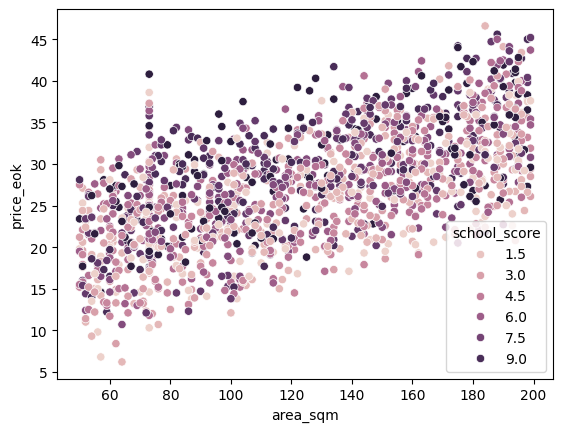

In [6]:
# 여기에 답안코드를 작성하세요.
import seaborn as sns

sns.scatterplot(estate_df, x="area_sqm", y="price_eok", hue="school_score")

#### **[해설 및 핵심 이론] 문제 3**


* **상세 해설**  
    `seaborn`의 `scatterplot`은 두 수치형 변수 간의 관계를 점으로 나타내는 산점도를 그립니다. `x`축에 `area_sqm`, `y`축에 `price_eok`를 설정하면 면적이 넓어질수록 가격이 높아지는 경향을 확인할 수 있습니다. 여기에 `hue='school_score'` 옵션을 추가하면, 각 점의 색상이 학군 점수에 따라 다르게 표시되어, 학군 점수가 높은(색이 밝은) 매물들이 전반적으로 높은 가격대에 분포하는 경향까지 한 번에 파악할 수 있습니다.

* **핵심 이론**
    * **`sns.scatterplot(data, x, y, hue)`**: 두 변수 간의 관계를 점으로 시각화합니다.
        * `hue`: 점의 색상을 결정할 제3의 변수를 지정합니다. 예를 들어, 면적(x)과 가격(y)의 관계를 보면서, 각 점의 색으로 학군 점수(hue)의 높고 낮음을 함께 표현할 수 있어 더 풍부한 분석이 가능합니다.
        * `palette`: `hue`에 사용할 색상 테마를 지정합니다.

<Axes: xlabel='area_sqm', ylabel='price_eok'>

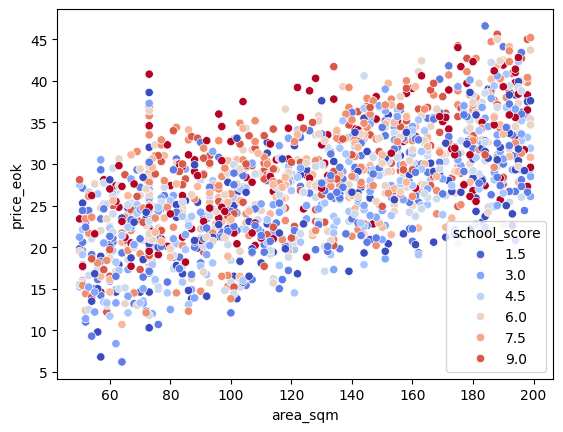

In [7]:
sns.scatterplot(data=estate_df, x='area_sqm', y='price_eok', hue='school_score', palette='coolwarm')

--- 
#### **문제 4.**

주요 건축 자재(`building_material`)에 따라 가격 분포가 어떻게 다른지 확인하려고 합니다. `seaborn`의 `violinplot`을 사용하여 `building_material`에 따른 `price_eok`의 분포를 시각화하고, 중앙값이 가장 큰 건축 자재를 `답안04` 변수에 문자열로 저장하세요.

* **x축**: `building_material`
* **y축**: `price_eok`
* **데이터**: `estate_df`

building_material
목조        27.55
벽돌        26.70
철근콘크리트    26.60
Name: price_eok, dtype: float64


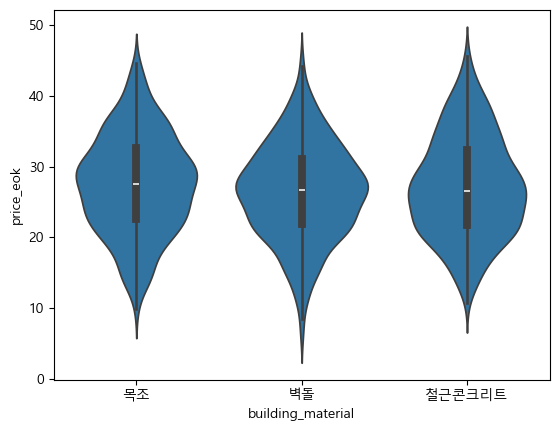

In [8]:
# 한글화를 위해 아래의 코드를 작성해 주세요.
import platform
from matplotlib import rc

if platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')
else:  # Windows
    rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

sns.violinplot(estate_df, x="building_material", y="price_eok")
print(estate_df.groupby("building_material")["price_eok"].median())

답안04="목조"

In [10]:
# 여기에 답안코드를 작성하세요.

답안04 = "목조"

#### **[해설 및 핵심 이론] 문제 4**


* **상세 해설**  
    `violinplot`은 `boxplot`의 장점과 데이터의 밀도(Density) 그래프의 장점을 합친 형태로, 각 그룹의 데이터 분포를 더 상세하게 보여줍니다. 마치 바이올린 모양처럼 생긴 이 그래프의 넓은 부분은 데이터가 많이 모여있는 곳, 좁은 부분은 데이터가 드문드문 있는 곳을 의미합니다. 그래프를 보면 '목조' 자재의 중앙값(바이올린 내부의 흰 점)이 다른 자재에 비해 가장 위쪽에 위치해 있어, 평균적으로 목조 건물의 가격이 가장 높다는 것을 알 수 있습니다.

* **핵심 이론**  
    * **`sns.violinplot(data, x, y)`**: `boxplot`처럼 중앙값, 사분위수 범위를 보여주면서 동시에 데이터의 전체적인 분포 형태(어디에 데이터가 몰려있는지)까지 시각적으로 표현합니다. 데이터가 특정 값에 몰려있는지, 아니면 여러 개의 봉우리를 갖는지 등을 파악하기에 용이합니다.

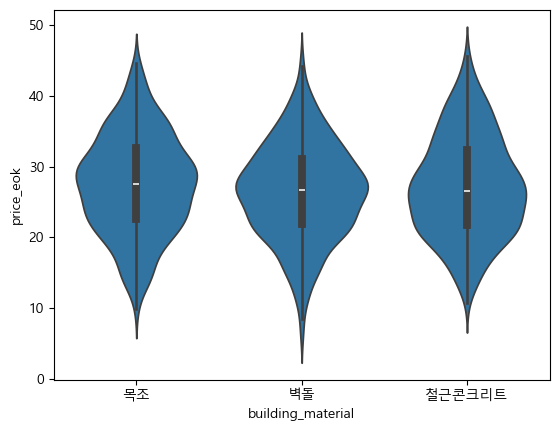

In [11]:
sns.violinplot(data=estate_df, x='building_material', y='price_eok')

# 그래프를 통해 '목조'의 중앙값이 가장 큰 것을 알 수 있습니다.
답안04 = '목조'

--- 
#### **문제 5.**

`region`별로 `subway_stations_1km`와 `amenities_500m`의 평균 개수를 확인하고자 합니다. `groupby()`를 사용하여 데이터를 `region`으로 그룹화하고, 두 편의시설 관련 컬럼의 평균을 계산하세요.

In [12]:
# 여기에 답안코드를 작성하세요.
region_infra_mean = estate_df.groupby(["region"])[["subway_stations_1km", "amenities_500m"]].mean()
print(display(region_infra_mean))

,subway_stations_1km,amenities_500m
region,,
강남,1.471132,7.055310
강북,1.387821,6.931464
기타,1.551471,6.579710
마포,1.475352,6.715753
서초,1.479021,7.016835


None


#### **[해설 및 핵심 이론] 문제 5**


* **상세 해설**  
    `groupby('region')`을 사용하여 데이터를 지역별로 그룹화합니다. 그 후, 분석 대상 컬럼인 `['subway_stations_1km', 'amenities_500m']`를 선택하고 `.mean()`으로 각 지역의 평균 편의시설 수를 계산합니다.

In [13]:
# 'region'으로 그룹화하여 지하철역 수와 편의시설 수의 평균을 계산합니다.
region_infra_mean = estate_df.groupby('region')[['subway_stations_1km', 'amenities_500m']].mean()
region_infra_mean

,subway_stations_1km,amenities_500m
region,,
강남,1.471132,7.055310
강북,1.387821,6.931464
기타,1.551471,6.579710
마포,1.475352,6.715753
서초,1.479021,7.016835


--- 
#### **문제 6.**

모델링을 위해 데이터의 결측치를 처리하려고 합니다. 아래 가이드에 따라 결측치를 처리하고, 결과를 `estate_pre` 변수에 저장하세요.

1.  `estate_df` 데이터프레임을 복사하여 `estate_pre`를 생성합니다.
2.  수치형 컬럼인 `num_rooms`, `num_bathrooms`, `building_age`, `parking_spaces`, `subway_stations_1km`의 결측치는 각 컬럼의 `중앙값(median)`으로 채우세요.
3.  범주형 컬럼인 `building_material`의 결측치는 **'unknown'** 문자열로 채우세요.

In [24]:
# 여기에 답안코드를 작성하세요.
estate_pre = estate_df.copy()
columns = ["num_rooms", "num_bathrooms", "building_age", "parking_spaces", "subway_stations_1km"]

for col in columns :
    errors = estate_pre[col].isnull().sum()
    estate_pre[col] = estate_pre[col].fillna(errors)

estate_pre["building_material"] = estate_pre["building_material"].fillna("unknown")
estate_pre.isnull().sum()
# estate_pre.fillna()

region                 0
area_sqm               0
num_rooms              0
num_bathrooms          0
building_age           0
building_material      0
parking_spaces         0
subway_stations_1km    0
amenities_500m         0
school_score           0
price_eok              0
dtype: int64

In [25]:
print(estate_pre.isnull().sum())

region                 0
area_sqm               0
num_rooms              0
num_bathrooms          0
building_age           0
building_material      0
parking_spaces         0
subway_stations_1km    0
amenities_500m         0
school_score           0
price_eok              0
dtype: int64


#### **[해설 및 핵심 이론] 문제 6**


* **상세 해설**  
    `copy()`로 데이터프레임을 복사합니다. 수치형 컬럼들의 리스트를 만들어 반복문을 통해 각 컬럼의 중앙값(`.median()`)을 계산하고, `fillna()`로 결측치를 채웁니다. 범주형 컬럼 `building_material`의 결측치는 `'unknown'` 문자열로 직접 채워줍니다. 수치형 데이터에서 평균 대신 중앙값을 사용하는 이유는, 이상치(outlier)의 영향을 덜 받기 때문입니다.

In [23]:
# 원본 보존을 위해 데이터프레임을 복사합니다.
estate_pre = estate_df.copy()

# 1. 수치형 컬럼 결측치를 중앙값으로 채우기
numeric_cols_with_na = ['num_rooms', 'num_bathrooms', 'building_age', 'parking_spaces', 'subway_stations_1km']
for col in numeric_cols_with_na:
    median_val = estate_pre[col].median()
    estate_pre[col].fillna(median_val, inplace=True)

# 2. 범주형 컬럼 결측치를 'unknown'으로 채우기
estate_pre['building_material'].fillna('unknown', inplace=True)

# 전처리 결과 확인
estate_pre.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               1500 non-null   str    
 1   area_sqm             1500 non-null   float64
 2   num_rooms            1456 non-null   float64
 3   num_bathrooms        1467 non-null   float64
 4   building_age         1459 non-null   float64
 5   building_material    1453 non-null   str    
 6   parking_spaces       1455 non-null   float64
 7   subway_stations_1km  1451 non-null   float64
 8   amenities_500m       1500 non-null   float64
 9   school_score         1500 non-null   float64
 10  price_eok            1500 non-null   float64
dtypes: float64(9), str(2)
memory usage: 129.0 KB


C:\Users\jungs\AppData\Local\Temp\ipykernel_11760\1171378295.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  estate_pre[col].fillna(median_val, inplace=True)
C:\Users\jungs\AppData\Local\Temp\ipykernel_11760\1171378295.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

--- 
#### **문제 7.**

머신러닝 모델이 이해할 수 있도록 범주형 데이터를 수치형으로 변환하려고 합니다.  
`sklearn.preprocessing`의 `LabelEncoder`를 사용하여 `region`과 `building_material` 컬럼을 각각 레이블 인코딩하세요.

* `LabelEncoder` 객체를 생성하여 각 컬럼에 `fit_transform`을 적용하고, 변환된 결과를 다시 원래 데이터프레임의 해당 컬럼에 덮어쓰세요.

In [26]:
# 여기에 답안코드를 작성하세요.
from sklearn.preprocessing import LabelEncoder

lbe = LabelEncoder()
estate_pre["region"] = lbe.fit_transform(estate_pre["region"])
estate_pre["building_material"] = lbe.fit_transform(estate_pre["building_material"])

print(estate_pre["region"].value_counts())
print(estate_pre["building_material"].value_counts())

print(estate_pre.isnull().sum())

region
0    452
1    321
4    297
3    292
2    138
Name: count, dtype: int64
building_material
1    498
2    481
3    474
0     47
Name: count, dtype: int64
region                 0
area_sqm               0
num_rooms              0
num_bathrooms          0
building_age           0
building_material      0
parking_spaces         0
subway_stations_1km    0
amenities_500m         0
school_score           0
price_eok              0
dtype: int64


#### **[해설 및 핵심 이론] 문제 7**


* **상세 해설**  
    `LabelEncoder`는 범주형 데이터를 0부터 시작하는 정수로 변환합니다. `region`과 `building_material` 각 컬럼에 대해 `LabelEncoder` 객체를 생성하고 `fit_transform`을 적용하여 변환된 숫자 배열을 다시 원래 컬럼에 덮어씁니다. 원-핫 인코딩과 달리 컬럼의 수가 늘어나지 않는 장점이 있지만, 모델이 '서울=0, 부산=1, 인천=2'일 때, '인천이 서울보다 수학적으로 더 크다'고 잘못 오해할 수 있는 단점도 있습니다.

* **핵심 이론**
    * **`LabelEncoder()`**: n개의 범주형 데이터를 0, 1, 2, ..., n-1 과 같은 정수로 변환합니다.
        * `.fit_transform(데이터)`: 데이터에 어떤 값들이 있는지 학습(fit)하고, 그 규칙에 따라 바로 변환(transform)을 수행합니다.

In [27]:
from sklearn.preprocessing import LabelEncoder

# 인코딩할 컬럼 리스트
categorical_cols_to_encode = ['region', 'building_material']

for col in categorical_cols_to_encode:
    # LabelEncoder 객체 생성
    le = LabelEncoder()
    # fit_transform을 적용하여 인코딩하고, 결과를 다시 해당 컬럼에 저장
    estate_pre[col] = le.fit_transform(estate_pre[col])

# 변환 결과 확인
estate_pre.head()

,region,area_sqm,num_rooms,num_bathrooms,building_age,building_material,parking_spaces,subway_stations_1km,amenities_500m,school_score,price_eok
0,4,105.0,4.0,3.0,12.0,1,1.0,1.0,11.0,7.0,29.7
1,4,105.0,2.0,3.0,13.0,1,2.0,3.0,2.0,3.0,29.6
2,0,128.0,1.0,2.0,18.0,2,2.0,49.0,11.0,9.0,30.3
3,0,137.0,2.0,1.0,13.0,2,2.0,0.0,5.0,3.0,29.1
4,4,115.0,1.0,1.0,38.0,3,1.0,3.0,10.0,4.0,26.4


In [28]:
print(estate_pre.isnull().sum())

region                 0
area_sqm               0
num_rooms              0
num_bathrooms          0
building_age           0
building_material      0
parking_spaces         0
subway_stations_1km    0
amenities_500m         0
school_score           0
price_eok              0
dtype: int64


--- 
#### **문제 8.**

훈련과 검증에 사용할 데이터셋을 분리하려고 합니다.  
`price_eok` 컬럼을 label `y`로, 나머지 컬럼들을 feature `X`로 할당한 후 훈련 데이터셋과 검증 데이터셋으로 분리하는 코드를 작성하세요.

* **대상 데이터셋**: `estate_pre` (7번 문제까지 처리 완료된)
* `sklearn.model_selection`의 `train_test_split` 함수 사용
* **훈련:검증 데이터 비율**: 80:20
* **`random_state`**: 42 (결과 재현을 위해 고정)

In [29]:
# 여기에 답안코드를 작성하세요.
from sklearn.model_selection import train_test_split

y = estate_pre["price_eok"]
X = estate_pre.drop("price_eok", axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.isnull().sum())

region                 0
area_sqm               0
num_rooms              0
num_bathrooms          0
building_age           0
building_material      0
parking_spaces         0
subway_stations_1km    0
amenities_500m         0
school_score           0
dtype: int64


In [30]:
print(X_valid.isnull().sum())

region                 0
area_sqm               0
num_rooms              0
num_bathrooms          0
building_age           0
building_material      0
parking_spaces         0
subway_stations_1km    0
amenities_500m         0
school_score           0
dtype: int64


#### **[해설 및 핵심 이론] 문제 8**


* **상세 해설**  
    `drop()`을 사용하여 `price_eok` 컬럼을 제외한 나머지를 `X`로, `price_eok` 컬럼을 `y`로 분리합니다.  
   `train_test_split` 함수에 `X`와 `y`, `test_size=0.2` (검증 데이터 20%), `random_state=42`를 설정하여 데이터를 분리합니다.

In [31]:
from sklearn.model_selection import train_test_split

# Feature(X)와 Label(y)을 분리합니다.
X = estate_pre.drop('price_eok', axis=1)
y = estate_pre['price_eok']

# 훈련 데이터와 검증 데이터로 분리합니다.
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 분리 결과 확인
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

print(X_train.isnull().sum())

X_train shape: (1200, 10)
X_valid shape: (300, 10)
region                 0
area_sqm               0
num_rooms              0
num_bathrooms          0
building_age           0
building_material      0
parking_spaces         0
subway_stations_1km    0
amenities_500m         0
school_score           0
dtype: int64


--- 
#### **문제 9.**

수치형 데이터들의 단위를 맞춰주기 위해 데이터 스케일링을 진행합니다.  
평균을 0, 표준편차를 1로 변환하는 `StandardScaler`를 사용하여 훈련 데이터와 검증 데이터의 Feature(`X_train`, `X_valid`)를 스케일링하는 코드를 작성하세요.

* `sklearn.preprocessing`의 `StandardScaler` 함수 사용
* 훈련 데이터에는 `fit_transform()`을, 검증 데이터에는 `transform()`을 적용하세요.
* 스케일링된 결과는 각각 `X_train_scaled`, `X_valid_scaled` 변수에 저장하세요.

In [32]:
# 여기에 답안코드를 작성하세요.
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print(np.isnan(X_train_scaled).sum())

0


#### **[해설 및 핵심 이론] 문제 9**


* **상세 해설**  
    `StandardScaler` 객체를 생성합니다. `MinMaxScaler`와 마찬가지로, **훈련 데이터(`X_train`)에는 `fit_transform()`을 적용**하여 스케일링 규칙(평균, 표준편차)을 학습하고 변환하며, **검증 데이터(`X_valid`)에는 `transform()`만 적용**하여 데이터 누수를 방지합니다.

* **핵심 이론**  
    * **`StandardScaler()`**: 각 특성의 평균을 0, 표준편차를 1이 되도록 데이터를 변환합니다. 마치 모든 학생의 점수를 반 평균과 비교하여 '평균보다 몇 점 위/아래'인지를 나타내는 '표준점수'로 바꾸는 것과 같습니다. 딥러닝을 포함한 많은 알고리즘에서 안정적인 성능을 보여 널리 사용됩니다.

In [33]:
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
scaler = StandardScaler()

# 훈련 데이터에 fit_transform 적용
X_train_scaled = scaler.fit_transform(X_train)

# 검증 데이터에 transform 적용
X_valid_scaled = scaler.transform(X_valid)

In [37]:
print(np.isnan(X_valid_scaled).sum())

0


--- 
#### **문제 10.**

선형 회귀 모델 중 하나인 `Ridge` 회귀 모델을 사용하여 부동산 가격 예측 모델을 학습시키려고 합니다. 아래 가이드에 따라 모델을 생성하고 학습시키는 코드를 작성하세요.  
`.predict()`를 사용하여 검증 데이터에 대한 예측값을 `ridge_pred`에 저장합니다.

* `sklearn.linear_model`의 `Ridge` 함수 사용
* **하이퍼파라미터 설정**:
    * `alpha`: 1.0
    * `random_state`: 42
* 모델 객체는 `model_ridge` 변수에 저장하고, 스케일링된 훈련 데이터로 학습시키세요.

In [38]:
# 여기에 답안코드를 작성하세요.
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


#### **[해설 및 핵심 이론] 문제 10**


* **상세 해설**
  
    `Ridge`는 기본적인 선형 회귀 모델에 '과적합 방지 장치'(L2 규제)를 추가한 모델입니다. 이 장치는 모델이 특정 데이터의 특징에 너무 과하게 반응(학습)하여, 새로운 데이터에 대한 예측력이 떨어지는 현상을 막아줍니다. `alpha` 값은 이 장치를 얼마나 강하게 작동시킬지를 조절하는 스위치와 같습니다.

* **핵심 이론**
    * **`Ridge(alpha)`**: 선형 회귀 모델의 한 종류로, 과적합(모델이 훈련 데이터에만 너무 맞춰지는 현상)을 제어하는 데 효과적입니다. `alpha` 값이 클수록 제어 장치가 강하게 작동하여 모델이 단순해지고, 작을수록 일반적인 선형 회귀 모델처럼 자유롭게 학습합니다.

In [73]:
from sklearn.linear_model import Ridge

# Ridge 모델 객체 생성
model_ridge = Ridge(alpha=1.0, random_state=42)

# 모델 학습
model_ridge.fit(X_train_scaled, y_train)

# 모델 예측
ridge_pred = model_ridge.predict(X_valid_scaled)

--- 
#### **문제 11.**

이번에는 `LGBMRegressor` 모델을 사용하여 학습을 진행하고, 이 모델의 예측 성능을 확인하려고 합니다. 아래 가이드에 따라 모델을 학습시키고, 검증 데이터셋(`X_valid_scaled`)에 대한 예측 결과를 `lgbm_pred` 변수에 저장하세요.

* `lightgbm`의 `LGBMRegressor` 함수 사용 (1번 문제에서 `lgb`로 임포트)
* **하이퍼파라미터 설정**:
    * `n_estimators`: 200
    * `learning_rate`: 0.05
    * `random_state`: 42
* 모델 객체는 `model_lgbm` 변수에 저장하고 학습시키세요.

In [39]:
# 여기에 답안코드를 작성하세요.
model_lgbm = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model_lgbm.fit(X_train_scaled, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 252
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 10
[LightGBM] [Info] Start training from score 27.126667


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [40]:
lgbm_predict = model_lgbm.predict(X_valid_scaled)
print(lgbm_predict)

[25.84421126 17.62744732 21.12477358 19.18464445 31.08883368 21.86585434
 27.98009941 30.05354747 27.62341054 20.01668917 18.79655653 27.94271808
 36.35891955 32.69981734 25.45948156 35.5724272  19.18665161 22.63023099
 17.90203752 32.47489723 27.4617131  34.07872739 31.12251135 40.77013246
 25.67049703 29.37854989 36.02099752 22.63227143 27.62493878 25.34616476
 25.32812833 17.92634846 31.29042803 31.05786069 34.10552975 32.77674955
 19.74000834 23.71492016 37.67583173 23.60345038 18.93697898 31.49174808
 37.06151053 19.37661813 16.32692519 21.51739271 21.76398714 28.39298939
 29.87275614 34.52252756 32.26628806 38.83911477 21.90689447 39.77840251
 24.12130089 25.13757347 25.80597724 30.62731064 29.01638784 30.26011691
 28.01308198 25.87775613 27.37722156 31.41549743 31.20134602 16.81372984
 26.44159693 15.55932851 16.95687128 29.66092875 23.03023521 27.10080664
 31.78979018 25.42226779 26.81243019 38.43785476 32.20566514 33.94714701
 32.11101369 25.42246999 23.52304956 38.49253309 20

c:\Users\jungs\Desktop\Code\AICE-associate\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#### **[해설 및 핵심 이론] 문제 11**

* **상세 해설**  
  
    `LGBMRegressor`는 XGBoost와 함께 그래디언트 부스팅 계열에서 가장 성능이 좋은 모델 중 하나로, 특히 대용량 데이터에서 빠른 학습 속도를 자랑합니다. 문제에서 제시된 하이퍼파라미터로 모델 객체 `model_lgbm`를 생성하고 학습시킨 후, `.predict()`를 사용하여 검증 데이터에 대한 예측값을 `lgbm_pred`에 저장합니다.

In [81]:
import lightgbm as lgb
    
# LGBMRegressor 모델 객체 생성
model_lgbm = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)

# 모델 학습
model_lgbm.fit(X_train_scaled, y_train)

# 검증 데이터에 대한 예측 수행
lgbm_pred = model_lgbm.predict(X_valid_scaled)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 252
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 10
[LightGBM] [Info] Start training from score 27.126667


c:\Users\jungs\Desktop\Code\AICE-associate\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


--- 
#### **문제 12.**

앞서 학습한 두 머신러닝 모델(`model_ridge`, `model_lgbm`)의 성능을 평가하려고 합니다.  
회귀 모델의 성능을 평가하는 대표적인 지표인 **MAE(Mean Absolute Error)** 와 **R² Score(결정계수)** 를 계산하는 코드를 작성하세요.

* `sklearn.metrics`에서 `mean_absolute_error`, `r2_score` 함수를 import하세요.
* 두 모델에 대해 각각 `y_valid`와 예측값을 사용하여 두 가지 평가지표를 모두 계산하고 출력하세요.

In [41]:
# 여기에 답안코드를 작성하세요.
from sklearn.metrics import mean_absolute_error, r2_score

pred_ridge = model_ridge.predict(X_valid)
print(mean_absolute_error(pred_ridge, y_valid))
print(r2_score(pred_ridge, y_valid))

pred_lgbm = model_lgbm.predict(X_valid)
print(mean_absolute_error(pred_lgbm, y_valid))
print(r2_score(pred_lgbm, y_valid))

493.58672747096796
-6.978341422247772
9.780050048841504
-23.014169180012832


c:\Users\jungs\Desktop\Code\AICE-associate\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


#### **[해설 및 핵심 이론] 문제 12**

* **상세 해설**
  
    `mean_absolute_error`와 `r2_score` 함수를 임포트합니다. 각 모델에 대해 예측값을 구하고, 평가 함수에 `(실제값, 예측값)` 순서로 인자를 넣어 성능 지표를 계산합니다. MAE는 (실제값 - 예측값)의 절댓값에 대한 평균으로, MSE(평균 제곱 오차)보다 이상치(매우 비싸거나 싼 특이한 매물)의 영향을 덜 받습니다. 또한 '평균적으로 약 3.5억 정도 오차가 난다'처럼 결과를 직관적으로 해석하기 좋은 장점이 있습니다.

* **핵심 이론**
    * **`mean_absolute_error(y_true, y_pred)`**: 평균 절대 오차를 계산합니다. (실제값 - 예측값)의 절댓값에 대한 평균이며, 값이 **작을수록** 좋습니다.
    * **`r2_score(y_true, y_pred)`**: 결정계수를 계산하며, **1에 가까울수록** 좋습니다.

In [42]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ridge 모델 성능 평가
ridge_mae = mean_absolute_error(y_valid, ridge_pred)
ridge_r2 = r2_score(y_valid, ridge_pred)

print("--- Ridge Regressor 성능 ---")
print(f"MAE: {ridge_mae:.4f}")
print(f"R² Score: {ridge_r2:.4f}\n")

# 2. LGBMRegressor 모델 성능 평가 (11번 문제의 예측값 사용)
lgbm_mae = mean_absolute_error(y_valid, lgbm_pred)
lgbm_r2 = r2_score(y_valid, lgbm_pred)

print("--- LGBMRegressor 성능 ---")
print(f"MAE: {lgbm_mae:.4f}")
print(f"R² Score: {lgbm_r2:.4f}")

NameError: name 'ridge_pred' is not defined

--- 
#### **문제 13.**

이번에는 딥러닝을 사용하여 가격 예측 모델을 만들려고 합니다.  
아래의 가이드에 따라 `tensorflow.keras`를 사용하여 회귀 모델을 구축하고 학습시키세요. 이번 모델에는 과적합을 방지하기 위해 `Dropout` 레이어를 추가합니다.

* `Sequential` 모델을 사용하세요.
* **모델 구조**:
    * **입력층**: `Dense` 레이어, 64개 노드, 활성화 함수 `relu`
    * **Dropout**: 20%의 뉴런을 비활성화 (`Dropout(0.2)`)
    * **은닉층 1**: `Dense` 레이어, 32개 노드, 활성화 함수 `relu`
    * **출력층**: `Dense` 레이어, **1개 노드**
* **컴파일 설정**:
    * `optimizer`: `adam`
    * `loss`: `mean_absolute_error` (MAE)
* **학습 설정**:
    * `epochs`: 100
    * `batch_size`: 16
    * `validation_split`: 훈련 데이터 중 20%를 검증용으로 사용
* 학습 과정은 `history` 변수에 저장하세요.

In [45]:
# 여기에 답안코드를 작성하세요.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential(
    [
        Dense(64, activation='relu', input_shape=[X_train_scaled.shape[1]]),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ]
)

model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2)

Epoch 1/100


c:\Users\jungs\Desktop\Code\AICE-associate\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 729.8783 - val_loss: 582.6829
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 439.7944 - val_loss: 202.7696
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 100.2033 - val_loss: 27.4842
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39.6660 - val_loss: 23.5132
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.1143 - val_loss: 22.7394
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 33.0542 - val_loss: 21.5531
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.7856 - val_loss: 20.1049
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.6370 - val_loss: 18.9539
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.0064 - val_loss: 17.8522
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.3040 - val_loss: 17.3050
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.0907 - val_loss: 16.2389
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

In [73]:
model.evaluate(X_valid_scaled, y_valid)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0717 


1.0717120170593262

#### **[해설 및 핵심 이론] 문제 13**

* **상세 해설**
  
    `Sequential` 모델을 만들고 `Dense` 레이어 사이에 `Dropout` 레이어를 추가합니다. `Dropout(0.2)`는 일종의 '팀워크 훈련' 장치입니다. 학습할 때마다 팀원(데이터를 처리하는 작은 단위인 뉴런) 중 20%를 무작위로 쉬게 만들어, 몇몇 에이스 팀원에게만 의존하지 않고 팀 전체가 협력하여 문제를 해결하는 능력을 기르도록 합니다. 이는 모델이 훈련 데이터에만 너무 익숙해지는 과적합 현상을 막는 데 매우 효과적입니다. `fit` 함수에서 `validation_split=0.2` 옵션은 별도의 검증 데이터를 지정하는 대신, 훈련 데이터의 마지막 20%를 검증용으로 사용하겠다는 의미입니다.

In [71]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 딥러닝 모델 설계
model_dl = Sequential([
    Dense(64, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# 모델 컴파일
model_dl.compile(optimizer='adam', loss='mean_absolute_error')

# 모델 학습
history = model_dl.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2, # 훈련 데이터의 20%를 검증용으로 사용
    verbose=0 # 학습 과정 출력 생략
)

print("딥러닝 모델 학습 완료")
model_dl.evaluate(X_valid_scaled, y_valid)

딥러닝 모델 학습 완료
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9107 


0.9106517434120178

--- 
#### **문제 14.**

최종적으로 완성된 딥러닝 모델을 사용하여, 아래와 같은 새로운 부동산 데이터가 들어왔을 때의 가격을 예측하려고 합니다.  
주어진 시뮬레이션 데이터(`new_estate_data`)를 **9번 문제에서 생성한 스케일러(`scaler`)를 사용하여 변환**한 뒤, 딥러닝 모델로 가격을 예측하는 코드를 작성하세요.

* 예측 결과는 `predicted_price_dl` 변수에 저장하세요.

In [52]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_estate_data = np.array([[0, 120.0, 3.0, 2.0, 10.0, 1, 2.0, 2.0, 8.0, 9.0]])
new_estate_data_predicted = scaler.transform(new_estate_data)

predicted_price_dl = model.predict(new_estate_data_predicted)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [53]:
print(f"{predicted_price_dl}")

[[19.53521]]


In [79]:
print(f"{predicted_price_dl}")

[[19.887245]]


In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 14**

* **상세 해설**

    새로운 데이터 `new_estate_data`는 스케일링되지 않은 원본 형태이므로, **반드시 9번 문제에서 훈련 데이터로 학습시킨 `scaler` 객체를 사용하여 `transform()`** 해야 합니다. 스케일링된 데이터를 학습된 딥러닝 모델 `model_dl`의 `.predict()` 메소드에 입력하여 가격을 예측하고, 그 결과를 `predicted_price_dl` 변수에 저장합니다.

In [ ]:
# 1. 9번 문제의 scaler를 사용하여 새로운 데이터를 스케일링합니다.
new_estate_scaled = scaler.transform(new_estate_data)

# 2. 딥러닝 모델로 가격을 예측합니다.
predicted_price_dl = model_dl.predict(new_estate_scaled)

print(f"새로운 부동산의 예측 가격: {predicted_price_dl[0][0]:.2f} 억원")